In [1]:
import pandas as pd

In [ ]:
#https://machinelearningmastery.com/time-series-forecasting-methods-in-python-cheat-sheet/

In [2]:
dataset=pd.read_csv("Tatacoffee13_21.csv",index_col="Date",parse_dates=True)

In [3]:
dataset.head()

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65


In [4]:
dataset.isnull().sum()

Open     0
High     0
Low      0
Close    0
dtype: int64

In [5]:
import datetime as dt
start = dt.datetime(2021,9,1)
end = dt.datetime(2022,2,4)

In [6]:
df = dataset.loc[start:end] # picking only the daterange provided in above

In [7]:
stk_data = df

In [8]:
column='Close'

In [9]:
column

'Close'

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()

In [11]:
data1 = Ms.fit_transform(stk_data[[column]])

In [12]:
data1.shape

(81, 1)

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(data1, order=(1,1,1), seasonal_order=(0,0,0,0))#Seasonal Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(0, len(data1)-1)
print(y_pred)
from stockFunctions import rmsemape # calling user defined function which contains metric calculation
rmsemape(data1,y_pred)
print("_______________")

[0.         0.40121212 0.3634109  0.3178728  0.23419485 0.42963133
 0.41951785 0.3930818  0.33379522 0.33149611 0.34409498 0.42922514
 0.33745605 0.18987814 0.19755246 0.27116114 0.28992213 0.21617863
 0.21744978 0.18642323 0.20939613 0.21786404 0.16729348 0.26449264
 0.26240175 0.44115191 0.57197808 0.58830307 0.54121808 0.80062832
 0.94796676 0.87046735 0.95775127 0.99822611 0.79273671 0.74815713
 0.59282258 0.43599106 0.48179369 0.48140524 0.37616765 0.32585371
 0.41649034 0.45895497 0.44234284 0.51443794 0.52044815 0.58473219
 0.62854012 0.60964069 0.63329819 0.74946403 0.73274771 0.8287995
 0.74912466 0.47548253 0.55189248 0.53510651 0.53709376 0.33269866
 0.1247623  0.20145091 0.24026427 0.26097429 0.23791804 0.19399258
 0.42698457 0.45680218 0.44199935 0.52849582 0.48759187 0.44722486
 0.40275039 0.32377723 0.23821324 0.00705509 0.12280436 0.2497266
 0.20371482 0.15760359 0.56658086]
RMSE-Testset: 0.12042529449358885
maPe-Testset: 13244655018278.89
_______________


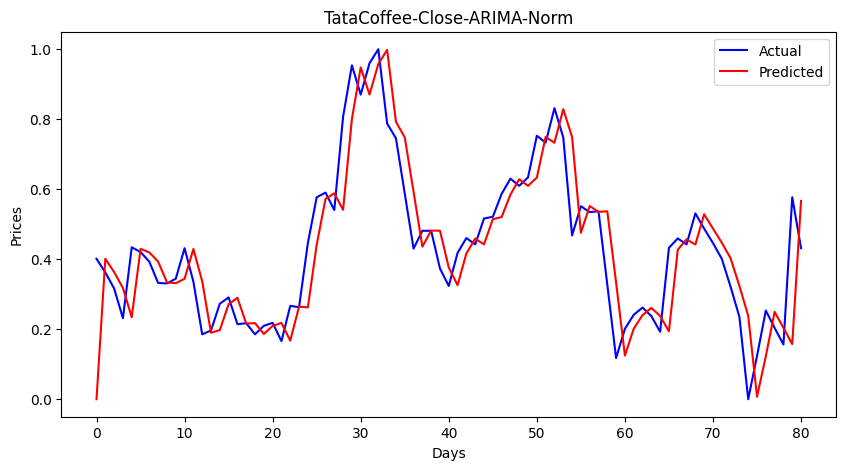

In [20]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","TataCoffee-Close-ARIMA-Norm","Days","Prices")

In [21]:
# Function does the same above for Acutal Test
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,[column])  # this call creates data frame and fill with y_test value
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)  # this call inverse the scaler value from dataframe into original value. Scaler expects DataFrame data
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column]) #this call creates dataframe

In [22]:
# Function does the same above for Predicted Test
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])  #Creating df for predicted value
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable) #inversing the scaler data into Original value 
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column]) # creating data frame.

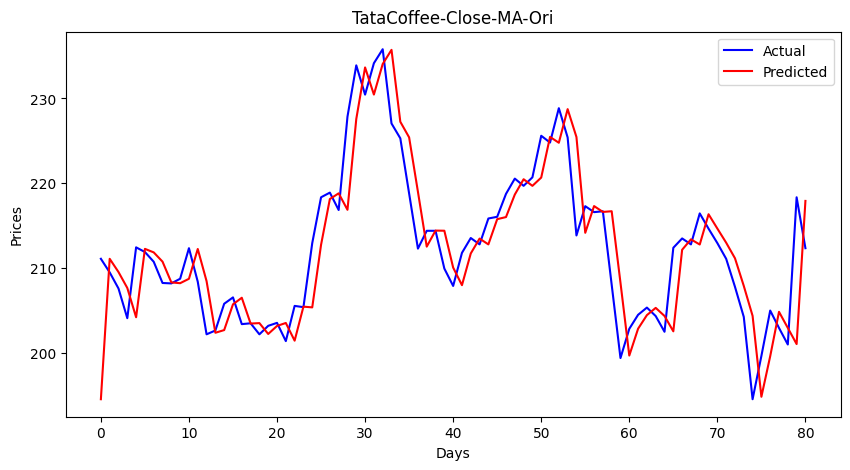

In [23]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")